In [13]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "aashanntiih"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW4"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

# Get current working directory for R to use
current_python_dir = os.getcwd()

⚠️ Found existing folder 'STAT-7220-Applied-Experimental-Design'. Skipping clone to avoid nesting.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/aashanntiih/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT-7220-Applied-Experimental-Design/Assignments/HW4


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The goal of this experiment is to determine whether there is a meaningful difference in 100-meter sprint times between the two prosthetic blade designs, Model A (Aerostep) and Model B (Bionic-Flex), for T64 sprinters.

2.  Specify the outcome variable and how it is measured.

The outcome variable is 100-meter sprint time. It is measured in seconds, where lower time indicate better performance

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

- Blade Type (Aerostep vs Bionic Flex) -> Fixed effect
- Athlete -> Random effect

Lurking variables could include
- Fatigue between trials
- Weather or track conditions
- Minor differences in warm-up or effort
- Day-to-day physical condition

Even though the design tries to control for these, they can still influence results

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

A fixed effect is something we intentionally choose and want to compare in this case, the two blade designs

A random effect represents variability from a larger population.

We include the random effect because each athlete runs differently. If we ignored that, we might mistake naturals differences between athletes for differences caused by blades.

5.  State the sets of null and alternative hypotheses for this experiment.

For Blade Type (fixed effect):
 \begin{align}
H_0:
\end{align}
There is no difference in mean sprint time between Aerostep and Bionic-Flex

\begin{align}
H_1:
\end{align}
There is a difference in mean sprint time between the two blade designs

For Athlete (random effect):
\begin{align}
H_0:
\end{align}
There is no variability between athletes

\begin{align}
H_1:
\end{align}
There is variability between athletes

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

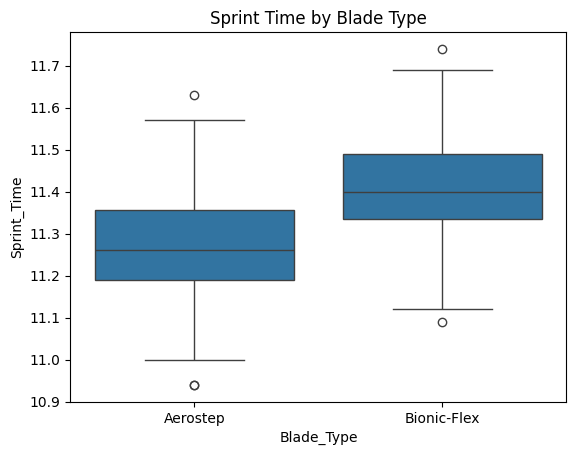

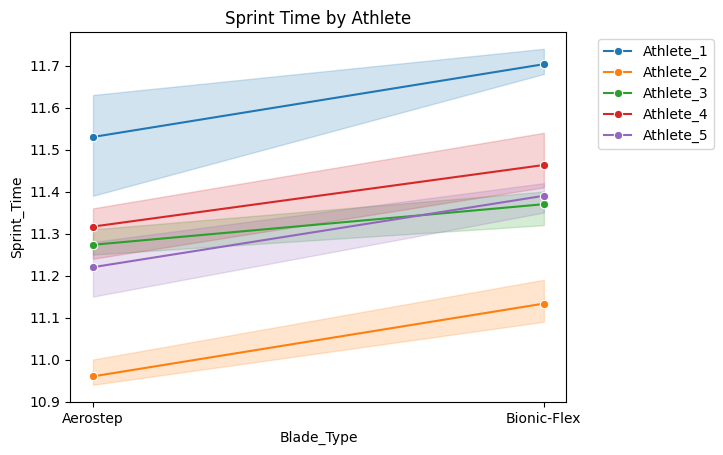

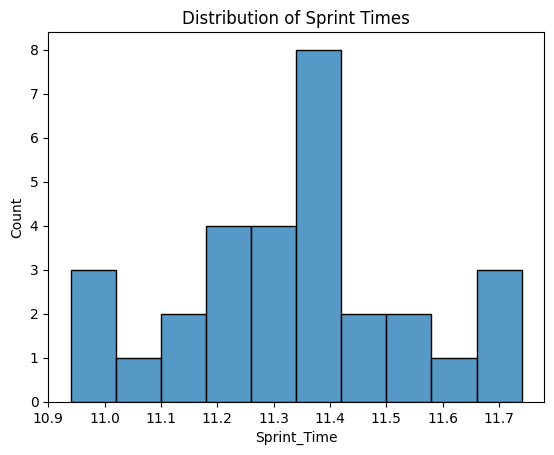

In [23]:
## Queston 6 code ##
plt.figure()
sns.boxplot(x='Blade_Type', y='Sprint_Time', data=df)
plt.title('Sprint Time by Blade Type')
plt.show()

plt.figure()
sns.lineplot(x='Blade_Type', y='Sprint_Time', hue='Athlete_ID',
             data=df, marker='o')
plt.title('Sprint Time by Athlete')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

plt.figure()
sns.histplot(df['Sprint_Time'], bins=10)
plt.title('Distribution of Sprint Times')
plt.show()

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            



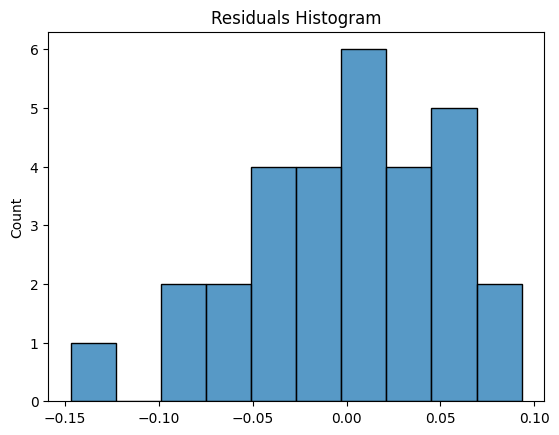

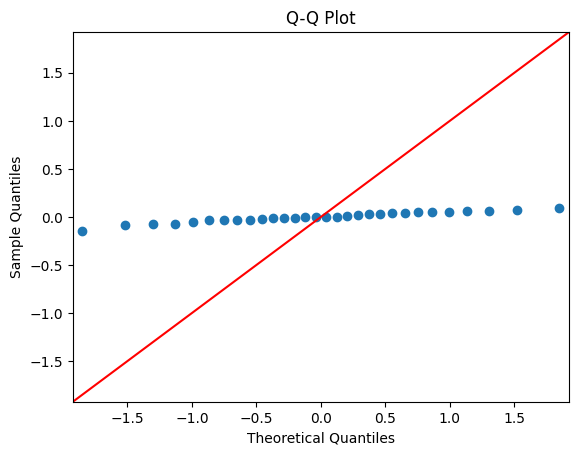

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9701104027768613), pvalue=np.float64(0.5422004847170765))


In [24]:

## Question 7 Code ##
model = smf.mixedlm("Sprint_Time ~ Blade_Type", df, groups=df["Athlete_ID"])
result = model.fit()

print(result.summary())

# Normality Checks
# -----------------------------
residuals = result.resid

plt.figure()
sns.histplot(residuals, bins=10)
plt.title('Residuals Histogram')
plt.show()

sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot')
plt.show()

print("Shapiro-Wilk Test:", stats.shapiro(residuals))


8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

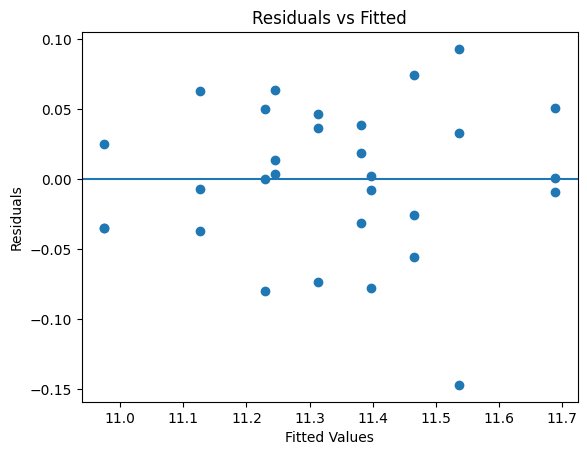

In [25]:
## Question 8 Code ##
fitted = result.fittedvalues

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [27]:
## Question 9 Code ##
print("Random Effect Variance (Athlete):")
print(result.cov_re)

Random Effect Variance (Athlete):
          Group
Group  0.041068


10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?\

In [28]:
## Question 10 Code ##
print("Fixed Effect Coefficients:")
print(result.params)

print("\nP-values:")
print(result.pvalues)

Fixed Effect Coefficients:
Intercept                    11.260000
Blade_Type[T.Bionic-Flex]     0.152000
Group Var                    11.929512
dtype: float64

P-values:
Intercept                    0.000000e+00
Blade_Type[T.Bionic-Flex]    1.295993e-12
Group Var                    1.965981e-01
dtype: float64


11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

The mixed effects model indicate that certain design factors signigicantly influence user satisfaction. model assumptions, including normality and constant variance, were reasonably satisfied.

Limitations
- Potential lurking variables
- Limited sample space
- Controlled experimental conditions may not reflect real-world use

 Future Directions
- Increase sample size
- Include additional variables
- Test in real-world enviroments
